In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

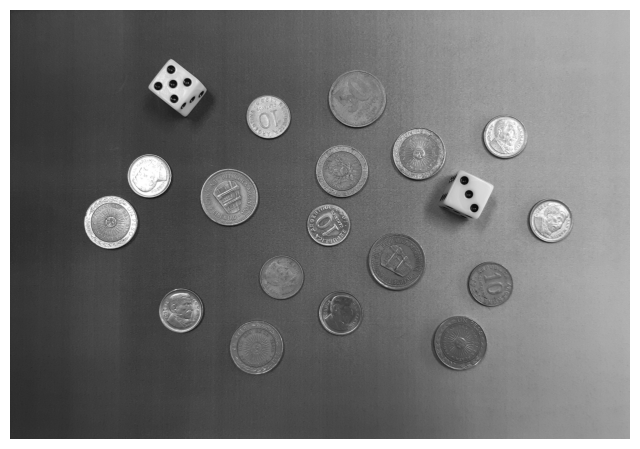

In [2]:
img = cv2.imread('img/monedas.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(8,6))
plt.imshow(img_gray, cmap='gray')
plt.axis('off'); plt.show()

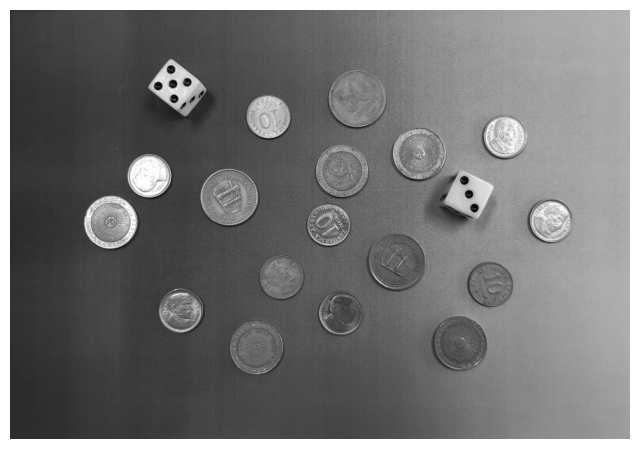

In [3]:
# suavizado
mask_blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.figure(figsize=(8,6))
plt.imshow(mask_blurred, cmap='gray')
plt.axis('off'); plt.show()

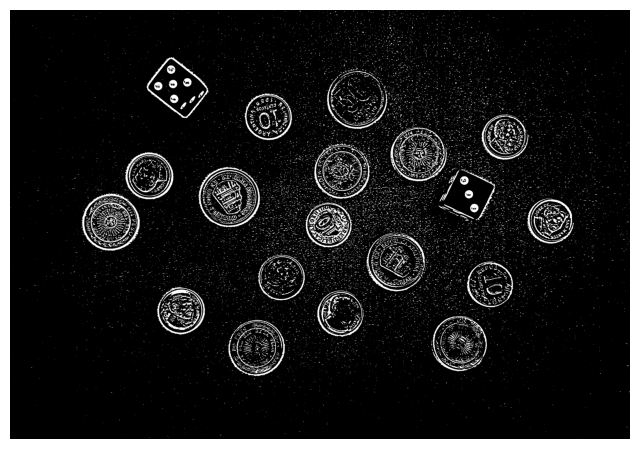

In [4]:
#umbralado local
mask_adaptive = cv2.adaptiveThreshold(
    mask_blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    51,  
    9   # mayor c menos ruido
)
plt.figure(figsize=(8,6))
plt.imshow(mask_adaptive, cmap='gray')
plt.axis('off'); plt.show()

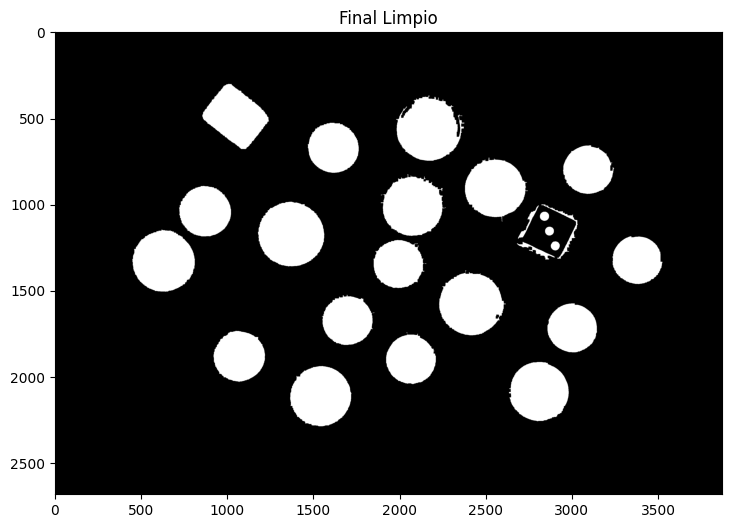

In [5]:
# Definir kernel
kernel = np.ones((3, 3), np.uint8)

mask_clean = cv2.morphologyEx(mask_adaptive, cv2.MORPH_OPEN, kernel, iterations=1)

mask_closed = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=6)

#filtrado por area
contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_final = np.zeros_like(img_gray)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1000: 
        cv2.drawContours(mask_final, [cnt], -1, 255, thickness=cv2.FILLED)

# Visualización
plt.figure(figsize=(12,6))
plt.imshow(mask_final, cmap='gray'); plt.title("Final Limpio")
plt.show()

In [6]:
def contar_puntos_dado(img_gray, x, y, w, h):
    m = 5
    roi = img_gray[y+m : y+h-m, x+m : x+w-m]
    if roi.size == 0: return 0
    blur = cv2.GaussianBlur(roi, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    cnts, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    puntos = 0
    
    for c in cnts:
        area = cv2.contourArea(c)
        perim = cv2.arcLength(c, True)
        if (60 < area < roi.size * 0.08) and (perim > 0) and \
           ((4 * np.pi * area) / (perim ** 2) > 0.75):
            puntos += 1
            
    return puntos

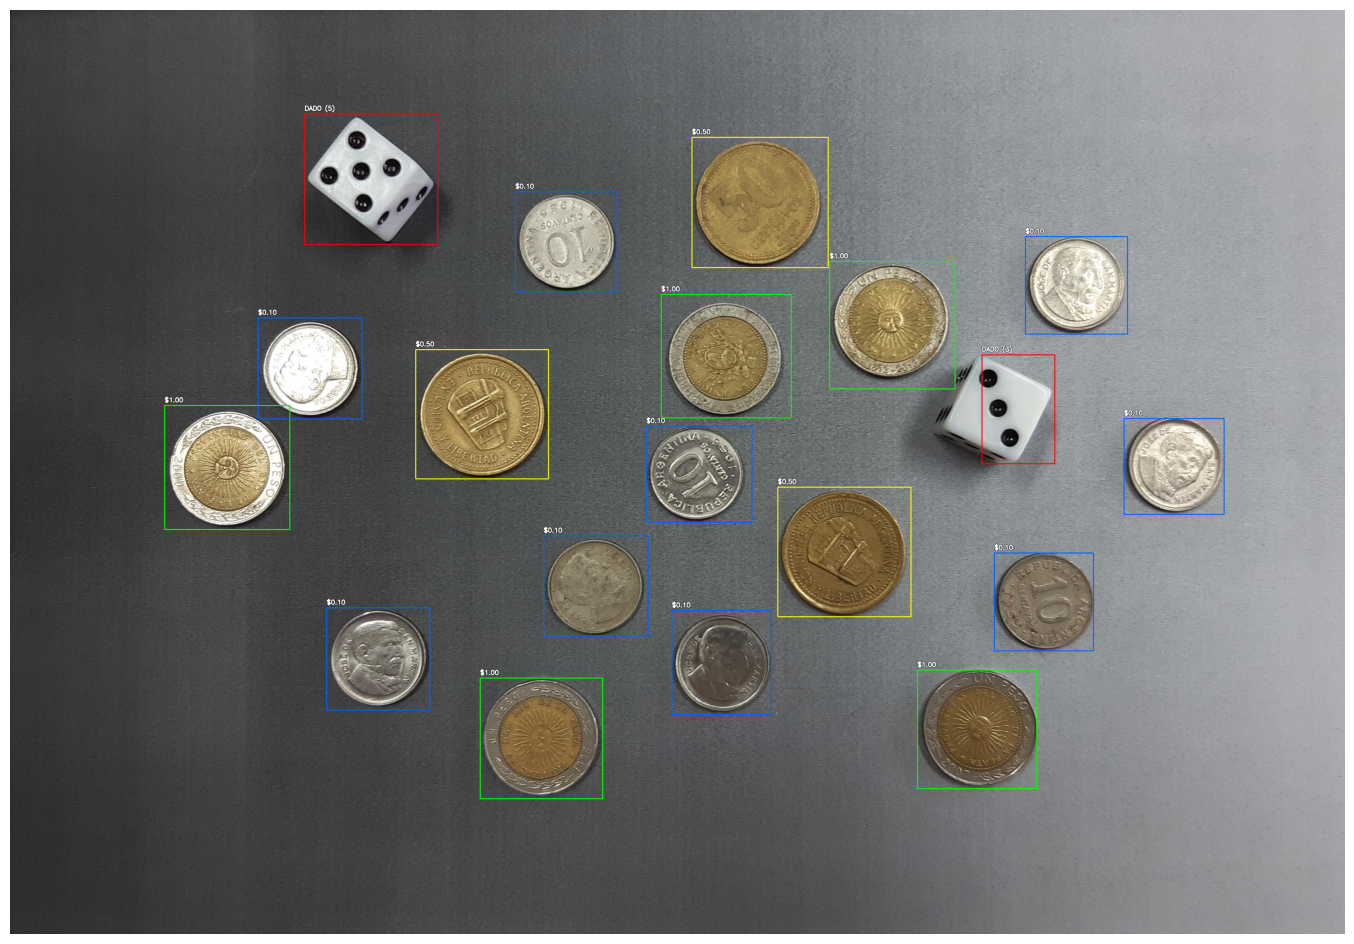

     Objeto  Cantidad
0     $0.10         9
1     $1.00         5
2     $0.50         3
3  DADO (3)         1
4  DADO (5)         1
TOTAL DINERO: $7.40


In [7]:
contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
output_image = img.copy()

data_lista = [] 

UMBRAL_TAMANO_PEQUENO = 310.0
UMBRAL_SAT_ANILLO = 60.0
UMBRAL_CIRCULARIDAD_DADO = 0.85 
UMBRAL_SAT_DADO = 50.0        


for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if area < 4000: continue 

    # GEOMETRÍA
    x, y, w, h = cv2.boundingRect(cnt)
    diametro = np.sqrt(4 * area / np.pi)
    
    perimeter = cv2.arcLength(cnt, True)
    epsilon = 0.03 * perimeter 
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    perimeter_smooth = cv2.arcLength(approx, True)
    
    circularity = 0
    if perimeter_smooth > 0:
        circularity = (4 * np.pi * area) / (perimeter_smooth ** 2)

    # COLOR
    mask_iso = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask_iso, [cnt], -1, 255, -1) 
    
    sat_global = cv2.mean(hsv_image, mask=mask_iso)[1]
    
    mask_anillo = cv2.subtract(mask_iso, cv2.erode(mask_iso, np.ones((15,15)), iterations=2))
    sat_anillo = cv2.mean(hsv_image, mask=mask_anillo)[1]

    #clasificacion
    etiqueta, color = "", (0,0,0)
    
    es_cuadrado = circularity < 0.82
    
    es_grande_y_blanco = (diametro >= UMBRAL_TAMANO_PEQUENO) and (sat_global < 25)

    if (es_cuadrado or es_grande_y_blanco) and sat_global < 60:
            num_puntos = contar_puntos_dado(img_gray, x, y, w, h)
            val_dado = num_puntos if num_puntos > 0 else "?"
            
            etiqueta = f"DADO ({val_dado})"
            color = (0, 0, 255) # Rojo     
        
    elif diametro < UMBRAL_TAMANO_PEQUENO:
        etiqueta, color = "$0.10", (255, 100, 0)
        
    elif sat_anillo < UMBRAL_SAT_ANILLO:
        etiqueta, color = "$1.00", (0, 255, 0)
        
    else:
        etiqueta, color = "$0.50", (0, 255, 255)

    data_lista.append(etiqueta)
    cv2.rectangle(output_image, (x, y), (x + w, y + h), color, 2)
    cv2.putText(output_image, etiqueta, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 4)
    cv2.putText(output_image, etiqueta, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)


plt.figure(figsize=(18,12))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.show()

df = pd.DataFrame(data_lista, columns=['Objeto'])
conteo_df = df['Objeto'].value_counts().reset_index(name='Cantidad')

precios = {'$1.00': 1.0, '$0.50': 0.5, '$0.10': 0.1, 'DADO': 0.0}
total = sum([precios.get(obj, 0) for obj in data_lista])

print(conteo_df)
print(f"TOTAL DINERO: ${total:.2f}")
